# Ateliê Generativo — Treinamento LoRA (Execução LOCAL)

Notebook-guia da **Etapa 2**, adaptado do template Colab para rodar **100% local**, em GPU NVIDIA própria via Jupyter/VS Code.

**Caminhos genéricos**: este notebook detecta automaticamente a raiz do projeto a partir da sua própria localização — funciona em qualquer PC do grupo, desde que a estrutura de pastas do repositório seja mantida.

**1 - Verificação do ambiente (PyTorch + CUDA)**

In [7]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'sem GPU detectada')

2.11.0+cu128
True
NVIDIA GeForce RTX 5070 Ti


In [8]:
import sys
print(sys.executable)  # confirma que o kernel está usando o .venv do projeto

g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art\.venv\Scripts\python.exe


**2 - Instalação de dependências (rodar uma única vez)**

In [9]:
import sys
!{sys.executable} -m pip install -q diffusers transformers accelerate peft datasets
# bitsandbytes é opcional e tem suporte instável no Windows nativo — só instale se for usar quantização
# !{sys.executable} -m pip install -q bitsandbytes

'g:\Faculdade\POS-GRADUACAO\Modelos' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


**3 - Caminhos genéricos do projeto**

`PROJECT_DIR` é calculado automaticamente a partir de onde este notebook está salvo — **não precisa editar nada aqui**, desde que a estrutura de pastas abaixo seja respeitada:

```
atelie-generativo-estilo-pixel-art/
├── notebooks/
│   └── 01_fine_tuning_LoRA_LOCAL.ipynb   ← este notebook
├── dataset/
│   ├── images/
│   └── legendas.txt
├── diffusers/                              ← repo clonado do HF
└── lora_outputs/                           ← criado automaticamente
```

Se você salvar o notebook em outro nível de pasta, ajuste apenas `NIVEIS_ATE_RAIZ` abaixo.

In [10]:
import os

# --- Detecção automática da raiz do projeto ---
# No Jupyter Notebook 'puro', __file__ não existe; por isso usamos os.getcwd().
# Ajuste NIVEIS_ATE_RAIZ se mudar a profundidade do notebook em relação à raiz:
#   0 = notebook está na raiz do projeto
#   1 = notebook está uma pasta abaixo (ex.: notebooks/)
NIVEIS_ATE_RAIZ = 1

PROJECT_DIR = os.getcwd()
for _ in range(NIVEIS_ATE_RAIZ):
    PROJECT_DIR = os.path.dirname(PROJECT_DIR)

PROJECT_DIR = os.path.abspath(PROJECT_DIR)
print('📁 Raiz do projeto detectada:', PROJECT_DIR)

📁 Raiz do projeto detectada: g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art


In [11]:
# Caminhos derivados — válidos em qualquer PC, contanto que a estrutura de pastas seja a mesma
DATASET_DIR = os.path.join(PROJECT_DIR, 'dataset')
IMAGES_DIR = os.path.join(DATASET_DIR, 'images')
DIFFUSERS_DIR = os.path.join(PROJECT_DIR, 'diffusers')
SCRIPT_PATH = os.path.join(DIFFUSERS_DIR, 'examples', 'text_to_image', 'train_text_to_image_lora.py')
OUTPUT_BASE = os.path.join(PROJECT_DIR, 'lora_outputs')

os.makedirs(OUTPUT_BASE, exist_ok=True)

print('Dataset dir   :', DATASET_DIR, '| existe:', os.path.isdir(DATASET_DIR))
print('Images dir    :', IMAGES_DIR, '| existe:', os.path.isdir(IMAGES_DIR))
print('Output base   :', OUTPUT_BASE)

assert os.path.isdir(DATASET_DIR), '❌ dataset/ não encontrado — confira NIVEIS_ATE_RAIZ acima'
os.makedirs(os.path.dirname(SCRIPT_PATH), exist_ok=True)  # a célula seguinte garante o script correto

Dataset dir   : g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art\dataset | existe: True
Images dir    : g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art\dataset\images | existe: True
Output base   : g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art\lora_outputs


**3.1 - Garantir versão compatível do diffusers (0.30.3) e do script de treino**

O script de exemplo distribuído no repositório `diffusers/` (branch `main`) costuma exigir uma versão de desenvolvimento mais nova do que a instalada via `pip`. Para manter a **mesma versão usada no notebook Colab da equipe** (evitando resultados inconsistentes entre quem treina local e quem treina no Colab), fixamos tudo na tag `v0.30.3`.

In [14]:
import sys
# Garante que a biblioteca diffusers instalada é a release 0.30.3 (mesma versão do notebook Colab)
%pip install -q "diffusers==0.30.3"

import diffusers
print('Versão diffusers instalada:', diffusers.__version__)
assert diffusers.__version__ == '0.30.3', '⚠️ Versão diferente da esperada — reinicie o kernel se acabou de instalar'

Note: you may need to restart the kernel to use updated packages.
Versão diffusers instalada: 0.30.3


In [15]:
import urllib.request

# Sobrescreve o script de treino com a versão correspondente à tag v0.30.3
# (em vez da versão 'main' do repositório clonado, que exige diffusers de desenvolvimento)
url_script = "https://raw.githubusercontent.com/huggingface/diffusers/v0.30.3/examples/text_to_image/train_text_to_image_lora.py"
urllib.request.urlretrieve(url_script, SCRIPT_PATH)

print('✅ Script train_text_to_image_lora.py (v0.30.3) salvo em:')
print(SCRIPT_PATH)
assert os.path.isfile(SCRIPT_PATH), '❌ Falha no download — confira sua conexão com a internet'

✅ Script train_text_to_image_lora.py (v0.30.3) salvo em:
g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art\diffusers\examples\text_to_image\train_text_to_image_lora.py


**4 - Geração do metadata.jsonl a partir de legendas.txt**

In [16]:
import json

txt_file = os.path.join(DATASET_DIR, 'legendas.txt')
jsonl_file = os.path.join(DATASET_DIR, 'metadata.jsonl')

assert os.path.isfile(txt_file), f'Arquivo não encontrado: {txt_file}'

n_linhas = 0
with open(txt_file, 'r', encoding='utf-8') as f_in, open(jsonl_file, 'w', encoding='utf-8') as f_out:
    for linha in f_in:
        linha = linha.strip()
        if not linha or ':' not in linha:
            continue
        arquivo, legenda = linha.split(':', 1)
        caminho_relativo = f"images/{arquivo.strip()}"
        json_obj = {"file_name": caminho_relativo, "text": legenda.strip()}
        f_out.write(json.dumps(json_obj, ensure_ascii=False) + '\n')
        n_linhas += 1

print(f'✅ metadata.jsonl gerado com {n_linhas} entradas em: {jsonl_file}')

✅ metadata.jsonl gerado com 100 entradas em: g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art\dataset\metadata.jsonl


In [17]:
# Validação: confirma que todas as imagens referenciadas no metadata.jsonl existem de fato
faltando = []
with open(jsonl_file, 'r', encoding='utf-8') as f:
    for linha in f:
        obj = json.loads(linha)
        caminho_completo = os.path.join(DATASET_DIR, obj['file_name'])
        if not os.path.isfile(caminho_completo):
            faltando.append(obj['file_name'])

if faltando:
    print(f'⚠️ {len(faltando)} imagem(ns) referenciada(s) no metadata.jsonl NÃO encontrada(s):')
    for f in faltando[:20]:
        print('  -', f)
else:
    print('✅ Todas as imagens referenciadas foram encontradas em dataset/images/')

✅ Todas as imagens referenciadas foram encontradas em dataset/images/


**5 - Configuração do Accelerate (rodar uma vez por máquina)**

In [18]:
from accelerate.utils import write_basic_config
write_basic_config()
print('🚀 Accelerate configurado para a GPU local desta máquina.')

Configuration already exists at C:\Users\rafam/.cache\huggingface\accelerate\default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.
🚀 Accelerate configurado para a GPU local desta máquina.


**6 - Treinamento: Configuração A (rank 8)**

Rápido, aprende características globais (cores, blocos do pixel art). Pode ter dificuldade com detalhes complexos.

In [21]:
import sys
os.chdir(PROJECT_DIR)

# barras forward funcionam em qualquer SO dentro de strings de comando
output_dir_a = os.path.join(OUTPUT_BASE, 'PixelArt_Rank8').replace(os.sep, '/')
dataset_dir_fwd = DATASET_DIR.replace(os.sep, '/')
script_fwd = SCRIPT_PATH.replace(os.sep, '/')

comando = (
    f'python -m accelerate.commands.launch "{script_fwd}" '
    f'--pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" '
    f'--train_data_dir="{dataset_dir_fwd}" '
    f'--dataloader_num_workers=0 '
    f'--resolution=512 '
    f'--center_crop --random_flip '
    f'--train_batch_size=1 '
    f'--gradient_accumulation_steps=4 '
    f'--max_train_steps=1000 '
    f'--learning_rate=1e-04 '
    f'--max_grad_norm=1 '
    f'--lr_scheduler="cosine" '
    f'--lr_warmup_steps=0 '
    f'--output_dir="{output_dir_a}" '
    f'--checkpointing_steps=500 '
    f'--seed=42 '
    f'--rank=8 '
    f'--mixed_precision="fp16"'
)
print(comando)
!{comando}

python -m accelerate.commands.launch "g:/Faculdade/POS-GRADUACAO/Modelos Multimodais/atelie-generativo-estilo-pixel-art/diffusers/examples/text_to_image/train_text_to_image_lora.py" --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" --train_data_dir="g:/Faculdade/POS-GRADUACAO/Modelos Multimodais/atelie-generativo-estilo-pixel-art/dataset" --dataloader_num_workers=0 --resolution=512 --center_crop --random_flip --train_batch_size=1 --gradient_accumulation_steps=4 --max_train_steps=1000 --learning_rate=1e-04 --max_grad_norm=1 --lr_scheduler="cosine" --lr_warmup_steps=0 --output_dir="g:/Faculdade/POS-GRADUACAO/Modelos Multimodais/atelie-generativo-estilo-pixel-art/lora_outputs/PixelArt_Rank8" --checkpointing_steps=500 --seed=42 --rank=8 --mixed_precision="fp16"


g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art\.venv\lib\site-packages\accelerate\accelerator.py:412: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art\.venv\lib\site-packages\accelerate\accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
06/25/2026 23:42:51 - INFO - __main__ - Distributed environment: NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

{'prediction_type', 'timestep_spacing', 'dynamic_thresholding_ratio', 'thresholding', 'clip_sample_range', 'rescale_betas_zero_snr', 'sample_max_value', 'variance_type'} was not 

**7 - Treinamento: Configuração B (rank 32)**

Captura detalhes mais finos do traço e estilo, mas tem leve risco de overfitting com dataset pequeno.

> Execute esta célula só depois que a Configuração A terminar.

In [ ]:
output_dir_b = os.path.join(OUTPUT_BASE, 'PixelArt_Rank32').replace(os.sep, '/')

comando_b = (
    f'{sys.executable} -m accelerate.commands.launch "{script_fwd}" '
    f'--pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" '
    f'--train_data_dir="{dataset_dir_fwd}" '
    f'--dataloader_num_workers=4 '
    f'--resolution=512 '
    f'--center_crop --random_flip '
    f'--train_batch_size=1 '
    f'--gradient_accumulation_steps=4 '
    f'--max_train_steps=1000 '
    f'--learning_rate=1e-04 '
    f'--max_grad_norm=1 '
    f'--lr_scheduler="cosine" '
    f'--lr_warmup_steps=0 '
    f'--output_dir="{output_dir_b}" '
    f'--checkpointing_steps=500 '
    f'--seed=42 '
    f'--rank=32 '
    f'--mixed_precision="fp16"'
)
print(comando_b)
!{comando_b}

**8 - Inferência e validação visual**

In [22]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16
)
pipe = pipe.to("cuda")

g:\Faculdade\POS-GRADUACAO\Modelos Multimodais\atelie-generativo-estilo-pixel-art\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rafam\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading pipeline components...:   0%|

In [23]:
# Carrega os pesos LoRA treinados (ajuste o checkpoint conforme o teste desejado)
caminho_do_lora = os.path.join(OUTPUT_BASE, 'PixelArt_Rank8', 'checkpoint-1000')
pipe.load_lora_weights(caminho_do_lora, weight_name="pytorch_lora_weights.safetensors")

W0626 00:05:50.670000 16704 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


🎨 Gerando imagem...


100%|██████████| 30/30 [00:02<00:00, 13.07it/s]


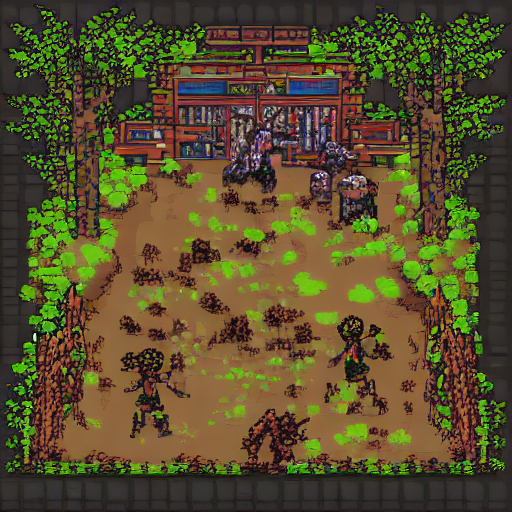

In [24]:
# Geração! Não esqueça de usar a sua Trigger Word ("estilo_pixel_art,")
prompt = "estilo_pixel_art, crie uma cena de luta entre magos."

print("🎨 Gerando imagem...")
imagem = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
display(imagem)